In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Energy Production Dataset.csv")

# Display basic information
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Dataset shape: (51864, 9)

Columns:
['Date', 'Start_Hour', 'End_Hour', 'Source', 'Day_of_Year', 'Day_Name', 'Month_Name', 'Season', 'Production']


,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,11/30/2025,21,22,Wind,334,Sunday,November,Fall,5281
1,11/30/2025,18,19,Wind,334,Sunday,November,Fall,3824
2,11/30/2025,16,17,Wind,334,Sunday,November,Fall,3824
3,11/30/2025,23,0,Wind,334,Sunday,November,Fall,6120
4,11/30/2025,6,7,Wind,334,Sunday,November,Fall,4387


In [ ]:
print("========== DATASET INFO ==========\n")
df.info()

print("\n========== DESCRIPTIVE STATISTICS ==========\n")
display(df.describe(include="all"))

========== DATASET INFO ==========

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51864 entries, 0 to 51863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         51864 non-null  object
 1   Start_Hour   51864 non-null  int64 
 2   End_Hour     51864 non-null  int64 
 3   Source       51864 non-null  object
 4   Day_of_Year  51864 non-null  int64 
 5   Day_Name     51864 non-null  object
 6   Month_Name   51864 non-null  object
 7   Season       51864 non-null  object
 8   Production   51864 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ MB

========== DESCRIPTIVE STATISTICS ==========



,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
count,51864,51864.000000,51864.000000,51864,51864.000000,51864,51864,51864,51864.000000
unique,2161,NaN,NaN,3,NaN,7,12,4,NaN
top,10/27/2024,NaN,NaN,Wind,NaN,Sunday,October,Summer,NaN
freq,25,NaN,NaN,42484,NaN,7416,4470,13248,NaN
mean,NaN,11.500000,11.500000,NaN,180.798415,NaN,NaN,NaN,6215.069933
std,NaN,6.922253,6.922253,NaN,104.291387,NaN,NaN,NaN,3978.364965
min,NaN,0.000000,0.000000,NaN,1.000000,NaN,NaN,NaN,58.000000
25%,NaN,5.750000,5.750000,NaN,91.000000,NaN,NaN,NaN,3111.000000
50%,NaN,11.500000,11.500000,NaN,181.000000,NaN,NaN,NaN,5372.000000
75%,NaN,17.250000,17.250000,NaN,271.000000,NaN,NaN,NaN,8501.000000


In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Date range:")
print("Minimum date:", df["Date"].min())
print("Maximum date:", df["Date"].max())

print("\nNumber of unique dates:", df["Date"].nunique())

Date range:
Minimum date: 2020-01-01 00:00:00
Maximum date: 2025-11-30 00:00:00

Number of unique dates: 2161


In [ ]:
print("========== RECORDS PER SOURCE ==========\n")

source_counts = df["Source"].value_counts()

display(source_counts)

# Percentage distribution
source_percentage = (
    df["Source"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nPercentage distribution:")
display(source_percentage)

========== RECORDS PER SOURCE ==========



,count
Source,
Wind,42484
Solar,9378
Mixed,2



Percentage distribution:


,proportion
Source,
Wind,81.91
Solar,18.08
Mixed,0.00


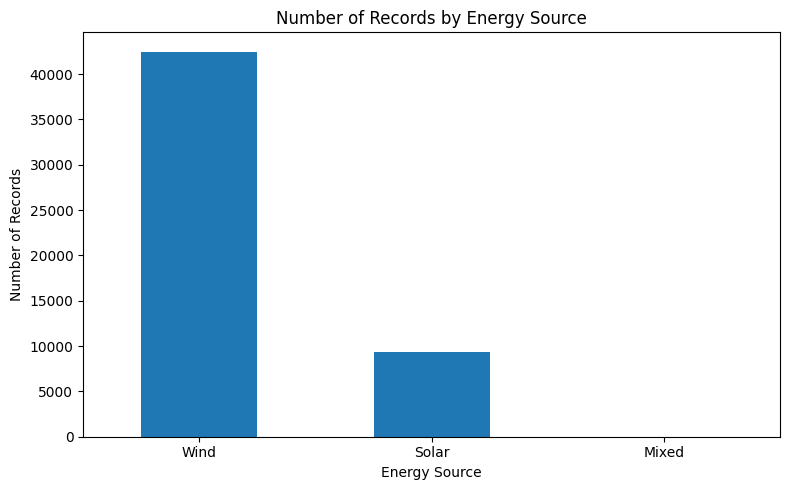

In [ ]:
plt.figure(figsize=(8, 5))

source_counts.plot(kind="bar")

plt.title("Number of Records by Energy Source")
plt.xlabel("Energy Source")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
daily_source_counts = (
    df.groupby(["Date", "Source"])
      .size()
      .reset_index(name="Record_Count")
)

print("========== RECORDS PER DAY/SOURCE ==========\n")

display(daily_source_counts.head(20))

print("\nSummary:")
display(daily_source_counts["Record_Count"].describe())

========== RECORDS PER DAY/SOURCE ==========



,Date,Source,Record_Count
0,2020-01-01,Solar,3
1,2020-01-01,Wind,21
2,2020-01-02,Wind,24
3,2020-01-03,Wind,24
4,2020-01-04,Wind,24
5,2020-01-05,Solar,5
6,2020-01-05,Wind,19
7,2020-01-06,Wind,24
8,2020-01-07,Wind,24
9,2020-01-08,Wind,24



Summary:


,Record_Count
count,3377.000000
mean,15.358010
std,6.941106
min,1.000000
25%,10.000000
50%,15.000000
75%,24.000000
max,25.000000


In [ ]:
print("Unique record counts per Date + Source:")

print(
    daily_source_counts["Record_Count"]
    .value_counts()
    .sort_index()
)

Unique record counts per Date + Source:
Record_Count
1      24
2      45
3      48
4      67
5      94
6     123
7     127
8     133
9     172
10    176
11    129
12    157
13    129
14    176
15    171
16    132
17    128
18    123
19     95
20     65
21     49
22     45
23     26
24    939
25      4
Name: count, dtype: int64


In [ ]:
print("\nMinimum records per Date + Source:",
      daily_source_counts["Record_Count"].min())

print("Maximum records per Date + Source:",
      daily_source_counts["Record_Count"].max())


Minimum records per Date + Source: 1
Maximum records per Date + Source: 25


In [ ]:
incomplete_days = daily_source_counts[
    daily_source_counts["Record_Count"] != 24
]

print("Number of Date + Source groups with != 24 records:",
      len(incomplete_days))

display(incomplete_days.head(20))

Number of Date + Source groups with != 24 records: 2438


,Date,Source,Record_Count
0,2020-01-01,Solar,3
1,2020-01-01,Wind,21
5,2020-01-05,Solar,5
6,2020-01-05,Wind,19
19,2020-01-18,Solar,5
20,2020-01-18,Wind,19
26,2020-01-24,Solar,6
27,2020-01-24,Wind,18
28,2020-01-25,Solar,4
29,2020-01-25,Wind,20


In [ ]:
print("========== MISSING VALUES ==========\n")

missing = df.isnull().sum()

missing_percentage = (
    df.isnull().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage
})

display(missing_report)

========== MISSING VALUES ==========



,Missing_Count,Missing_Percentage
Date,0,0.0
Start_Hour,0,0.0
End_Hour,0,0.0
Source,0,0.0
Day_of_Year,0,0.0
Day_Name,0,0.0
Month_Name,0,0.0
Season,0,0.0
Production,0,0.0


In [ ]:
invalid_dates = df["Date"].isna().sum()

print("Invalid/missing dates:", invalid_dates)

Invalid/missing dates: 0


In [ ]:
print("========== DUPLICATE ROWS ==========\n")

duplicate_count = df.duplicated().sum()

print("Number of completely duplicated rows:", duplicate_count)

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].sort_values("Date").head(20))

========== DUPLICATE ROWS ==========

Number of completely duplicated rows: 0


In [ ]:
key_columns = [
    "Date",
    "Start_Hour",
    "End_Hour",
    "Source"
]

key_duplicates = df.duplicated(
    subset=key_columns,
    keep=False
)

print(
    "Duplicate Date + Hour + Source combinations:",
    key_duplicates.sum()
)

if key_duplicates.sum() > 0:
    display(
        df[key_duplicates]
        .sort_values(key_columns)
        .head(30)
    )

Duplicate Date + Hour + Source combinations: 12


,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
44698,2020-10-25,2,3,Wind,299,Sunday,October,Fall,11001
44707,2020-10-25,2,3,Wind,299,Sunday,October,Fall,10696
35784,2021-10-31,2,3,Wind,304,Sunday,October,Fall,4784
35795,2021-10-31,2,3,Wind,304,Sunday,October,Fall,4462
27057,2022-10-30,2,3,Wind,303,Sunday,October,Fall,3262
27063,2022-10-30,2,3,Wind,303,Sunday,October,Fall,3107
18321,2023-10-29,2,3,Wind,302,Sunday,October,Fall,15488
18328,2023-10-29,2,3,Wind,302,Sunday,October,Fall,15218
9577,2024-10-27,2,3,Wind,301,Sunday,October,Fall,1876
9581,2024-10-27,2,3,Wind,301,Sunday,October,Fall,1601


In [ ]:
print("========== PRODUCTION BY SOURCE ==========\n")

production_by_source = (
    df.groupby("Source")["Production"]
      .agg([
          "count",
          "mean",
          "median",
          "std",
          "min",
          "max"
      ])
      .round(2)
)

display(production_by_source)

========== PRODUCTION BY SOURCE ==========



,count,mean,median,std,min,max
Source,,,,,,
Mixed,2,1737.00,1737.0,1418.46,734,2740
Solar,9378,5793.85,5500.5,2412.68,267,16578
Wind,42484,6308.26,5317.5,4241.26,58,23446


<Figure size 1000x600 with 0 Axes>

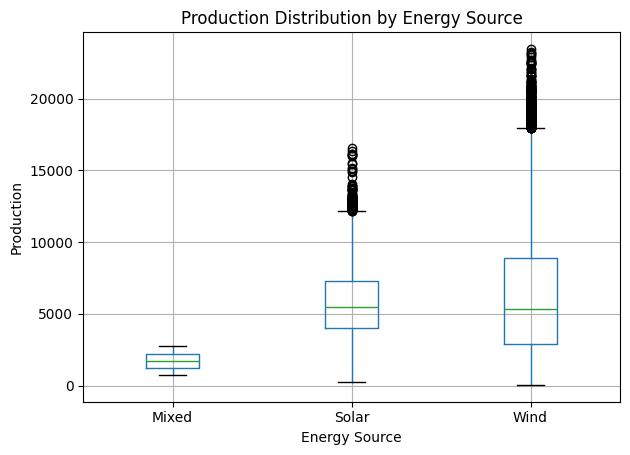

In [ ]:
plt.figure(figsize=(10, 6))

df.boxplot(
    column="Production",
    by="Source"
)

plt.title("Production Distribution by Energy Source")
plt.suptitle("")
plt.xlabel("Energy Source")
plt.ylabel("Production")
plt.tight_layout()
plt.show()

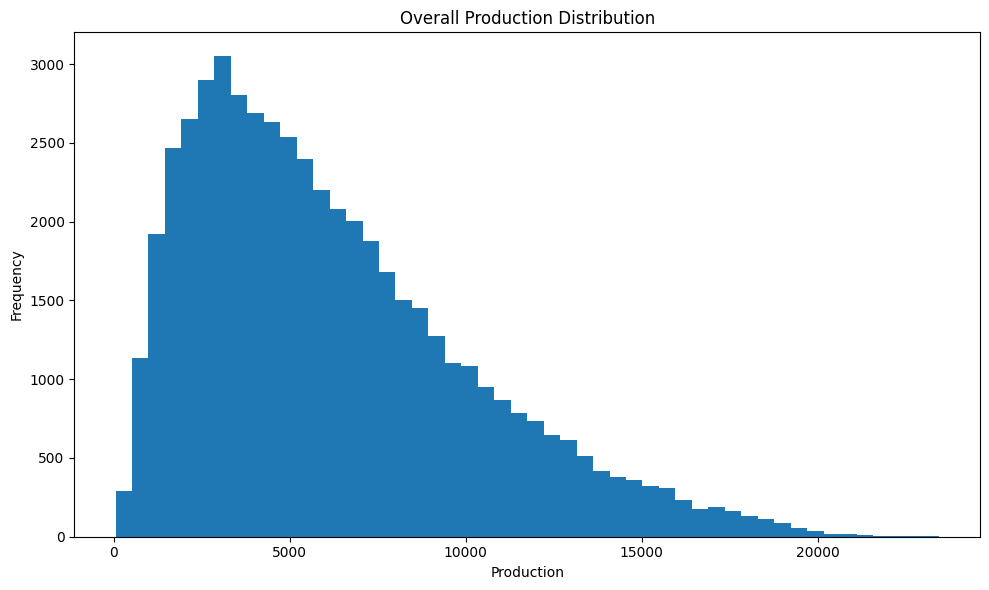

In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Production"].dropna(),
    bins=50
)

plt.title("Overall Production Distribution")
plt.xlabel("Production")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
print("========== PRODUCTION STATISTICS ==========\n")

display(
    df["Production"]
    .describe()
    .round(2)
)

========== PRODUCTION STATISTICS ==========



,Production
count,51864.00
mean,6215.07
std,3978.36
min,58.00
25%,3111.00
50%,5372.00
75%,8501.00
max,23446.00


In [ ]:
daily_production = (
    df.groupby("Date")["Production"]
      .sum()
      .reset_index()
)

display(daily_production.head())

,Date,Production
0,2020-01-01,47222
1,2020-01-02,89374
2,2020-01-03,179487
3,2020-01-04,84640
4,2020-01-05,49253


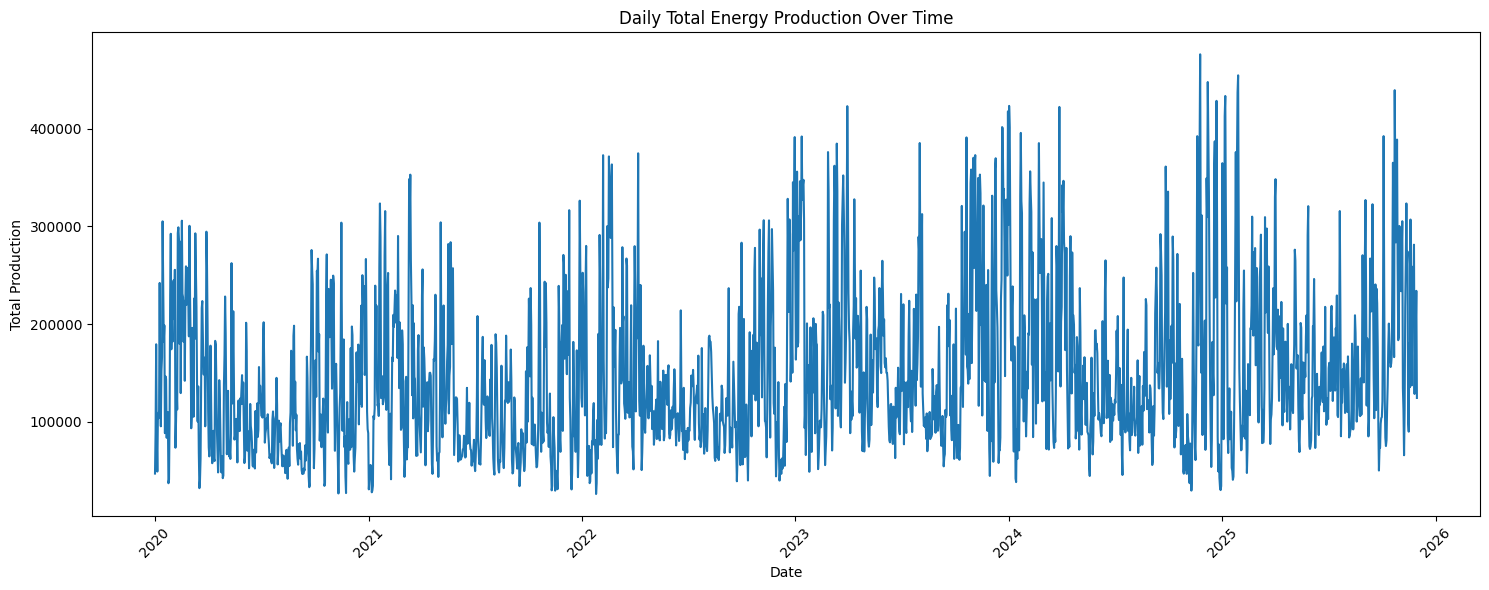

In [ ]:
plt.figure(figsize=(15, 6))

plt.plot(
    daily_production["Date"],
    daily_production["Production"]
)

plt.title("Daily Total Energy Production Over Time")
plt.xlabel("Date")
plt.ylabel("Total Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

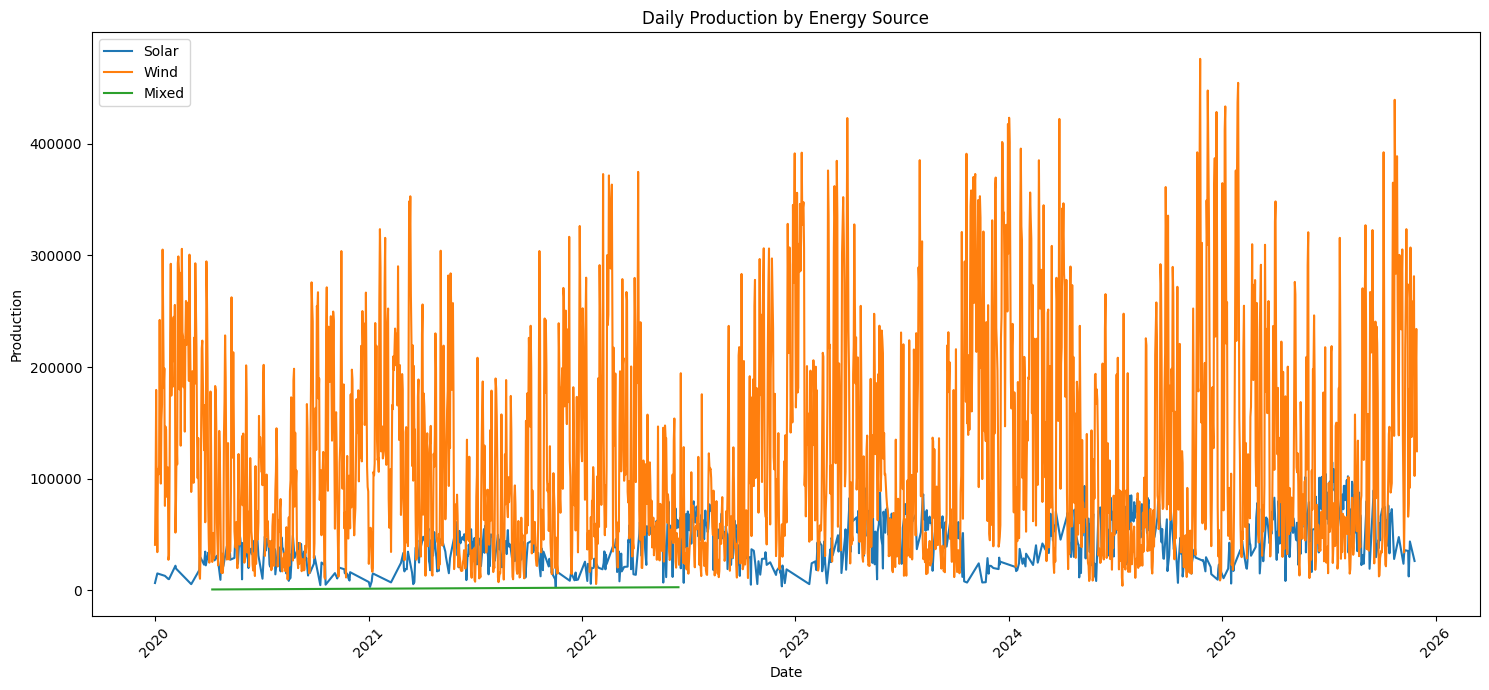

In [ ]:
daily_source_production = (
    df.groupby(["Date", "Source"])["Production"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(15, 7))

for source in daily_source_production["Source"].unique():

    source_data = daily_source_production[
        daily_source_production["Source"] == source
    ]

    plt.plot(
        source_data["Date"],
        source_data["Production"],
        label=source
    )

plt.title("Daily Production by Energy Source")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
hourly_production = (
    df.groupby("Start_Hour")["Production"]
      .agg(["mean", "median", "std"])
)

display(hourly_production.round(2))

,mean,median,std
Start_Hour,,,
0,5313.70,4307.0,3693.88
1,5208.01,4131.0,3655.01
2,5087.77,3997.0,3616.51
3,4972.21,3930.0,3567.58
4,4884.65,3804.0,3564.24
5,4849.28,3806.0,3597.43
6,4869.56,3755.0,3627.59
7,5086.39,3910.0,3686.09
8,5491.74,4364.0,3642.46


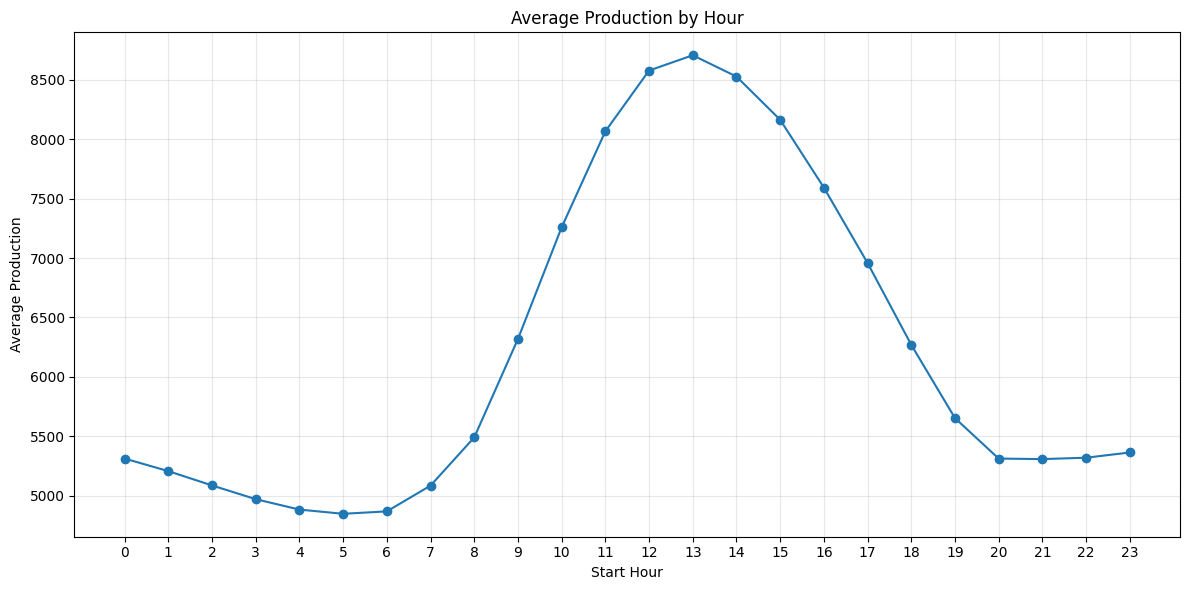

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_production.index,
    hourly_production["mean"],
    marker="o"
)

plt.title("Average Production by Hour")
plt.xlabel("Start Hour")
plt.ylabel("Average Production")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

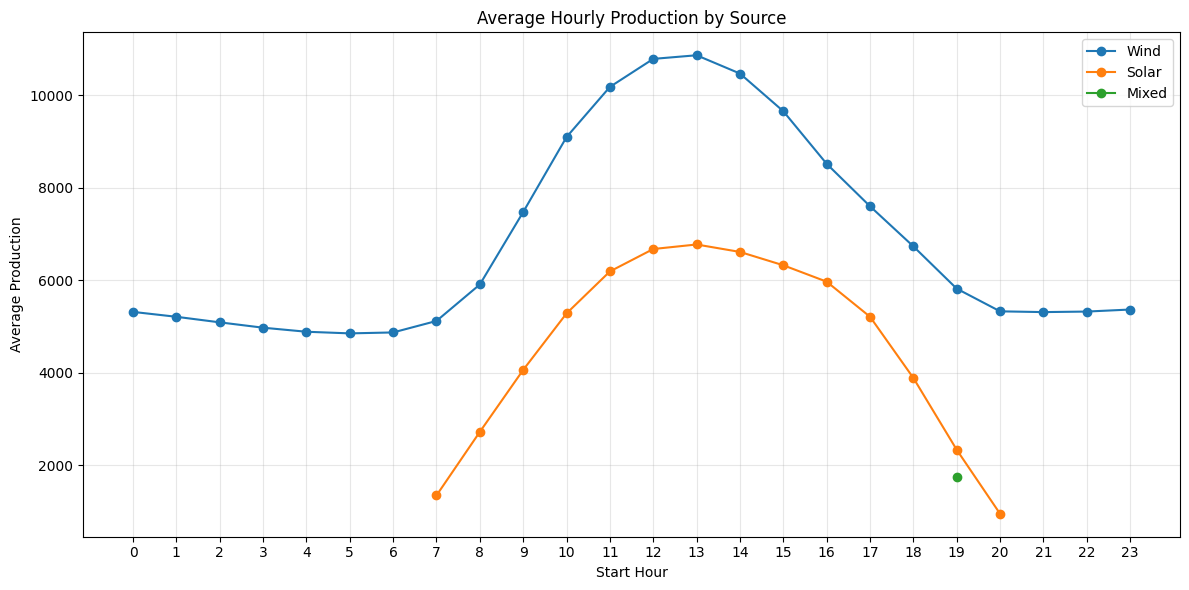

In [ ]:
hourly_source = (
    df.groupby(["Start_Hour", "Source"])["Production"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 6))

for source in hourly_source["Source"].unique():

    source_data = hourly_source[
        hourly_source["Source"] == source
    ]

    plt.plot(
        source_data["Start_Hour"],
        source_data["Production"],
        marker="o",
        label=source
    )

plt.title("Average Hourly Production by Source")
plt.xlabel("Start Hour")
plt.ylabel("Average Production")
plt.xticks(range(24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("Unique production values:",
      df["Production"].nunique())

print(
    "Total production records:",
    len(df)
)

print(
    "Percentage of unique production values:",
    round(
        df["Production"].nunique() /
        len(df) * 100,
        2
    ),
    "%"
)

Unique production values: 14617
Total production records: 51864
Percentage of unique production values: 28.18 %


In [ ]:
production_frequency = (
    df["Production"]
    .value_counts()
    .head(20)
)

print("Most frequent production values:")

display(production_frequency)

Most frequent production values:


,count
Production,
5374,17
3540,15
2925,15
3181,14
3923,14
2543,14
2137,14
2726,14
3165,14


In [ ]:
feature_columns = [
    "Start_Hour",
    "End_Hour",
    "Source",
    "Day_of_Year",
    "Day_Name",
    "Month_Name",
    "Season"
]

variation_check = (
    df.groupby(feature_columns)["Production"]
      .nunique()
      .reset_index(name="Unique_Production_Values")
)

print("Feature combinations with multiple production values:")

display(
    variation_check[
        variation_check["Unique_Production_Values"] > 1
    ].head(20)
)

Feature combinations with multiple production values:


,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Unique_Production_Values
4,0,1,Wind,1,Wednesday,January,Winter,2
8,0,1,Wind,2,Thursday,January,Winter,2
10,0,1,Wind,3,Friday,January,Winter,2
16,0,1,Wind,4,Saturday,January,Winter,2
21,0,1,Wind,5,Sunday,January,Winter,2
26,0,1,Wind,6,Monday,January,Winter,2
34,0,1,Wind,7,Tuesday,January,Winter,2
39,0,1,Wind,8,Wednesday,January,Winter,2
43,0,1,Wind,9,Thursday,January,Winter,2
45,0,1,Wind,10,Friday,January,Winter,2


In [ ]:
print(
    "Total feature combinations:",
    len(variation_check)
)

print(
    "Combinations producing exactly one production value:",
    (variation_check["Unique_Production_Values"] == 1).sum()
)

print(
    "Combinations producing multiple production values:",
    (variation_check["Unique_Production_Values"] > 1).sum()
)

Total feature combinations: 45516
Combinations producing exactly one production value: 39171
Combinations producing multiple production values: 6345


In [ ]:
df["Year"] = df["Date"].dt.year

year_counts = df["Year"].value_counts().sort_index()

print("========== RECORDS BY YEAR ==========\n")

display(year_counts)

========== RECORDS BY YEAR ==========



,count
Year,
2020,8784
2021,8760
2022,8760
2023,8760
2024,8784
2025,8016


In [ ]:
year_date_range = (
    df.groupby("Year")["Date"]
      .agg(["min", "max", "nunique"])
)

display(year_date_range)

,min,max,nunique
Year,,,
2020,2020-01-01,2020-12-31,366
2021,2021-01-01,2021-12-31,365
2022,2022-01-01,2022-12-31,365
2023,2023-01-01,2023-12-31,365
2024,2024-01-01,2024-12-31,366
2025,2025-01-01,2025-11-30,334


In [ ]:
monthly_counts = (
    df.groupby(["Year", df["Date"].dt.month])
      .size()
      .unstack(fill_value=0)
)

display(monthly_counts)

Date,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2020,744,696,743,720,744,720,744,744,720,745,720,744
2021,744,672,743,720,744,720,744,744,720,745,720,744
2022,744,672,743,720,744,720,744,744,720,745,720,744
2023,744,672,743,720,744,720,744,744,720,745,720,744
2024,744,696,743,720,744,720,744,744,720,745,720,744
2025,744,672,743,720,744,720,744,744,720,745,720,0


In [ ]:
dates_2025 = (
    df.loc[df["Year"] == 2025, "Date"]
      .drop_duplicates()
      .sort_values()
)

print("Number of unique dates in 2025:",
      len(dates_2025))

print("Expected dates in 2025:",
      365)

Number of unique dates in 2025: 334
Expected dates in 2025: 365


In [ ]:
expected_2025_dates = pd.date_range(
    start="2025-01-01",
    end="2025-12-31",
    freq="D"
)

missing_2025_dates = expected_2025_dates.difference(
    dates_2025
)

print("Missing dates in 2025:",
      len(missing_2025_dates))

if len(missing_2025_dates) > 0:
    print(missing_2025_dates)

Missing dates in 2025: 31
DatetimeIndex(['2025-12-01', '2025-12-02', '2025-12-03', '2025-12-04',
               '2025-12-05', '2025-12-06', '2025-12-07', '2025-12-08',
               '2025-12-09', '2025-12-10', '2025-12-11', '2025-12-12',
               '2025-12-13', '2025-12-14', '2025-12-15', '2025-12-16',
               '2025-12-17', '2025-12-18', '2025-12-19', '2025-12-20',
               '2025-12-21', '2025-12-22', '2025-12-23', '2025-12-24',
               '2025-12-25', '2025-12-26', '2025-12-27', '2025-12-28',
               '2025-12-29', '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', freq='D')


In [ ]:
df_2025 = df[df["Year"] == 2025].copy()

hours_per_day_2025 = (
    df_2025.groupby("Date")
           .size()
)

print("Hourly records per date in 2025:")
display(
    hours_per_day_2025.value_counts()
    .sort_index()
)

Hourly records per date in 2025:


,count
23,1
24,332
25,1


In [ ]:
incomplete_2025_days = hours_per_day_2025[
    hours_per_day_2025 != 24
]

print(
    "2025 dates with != 24 records:",
    len(incomplete_2025_days)
)

display(incomplete_2025_days.head(20))

2025 dates with != 24 records: 2


,0
Date,
2025-03-30,23
2025-10-26,25


In [ ]:
df = df.sort_values(
    ["Source", "Date", "Start_Hour"]
).reset_index(drop=True)

In [ ]:
df["Production_Lag_1"] = (
    df.groupby("Source")["Production"]
      .shift(1)
)

In [ ]:
df["Production_Lag_24"] = (
    df.groupby("Source")["Production"]
      .shift(24)
)

In [ ]:
df["Production_Lag_168"] = (
    df.groupby("Source")["Production"]
      .shift(168)
)

In [ ]:
lag_columns = [
    "Production",
    "Production_Lag_1",
    "Production_Lag_24",
    "Production_Lag_168"
]

print("========== LAG CORRELATIONS ==========\n")

display(
    df[lag_columns]
    .corr()
    .round(3)
)

========== LAG CORRELATIONS ==========



,Production,Production_Lag_1,Production_Lag_24,Production_Lag_168
Production,1.000,0.971,0.474,0.147
Production_Lag_1,0.971,1.000,0.488,0.147
Production_Lag_24,0.474,0.488,1.000,0.149
Production_Lag_168,0.147,0.147,0.149,1.000


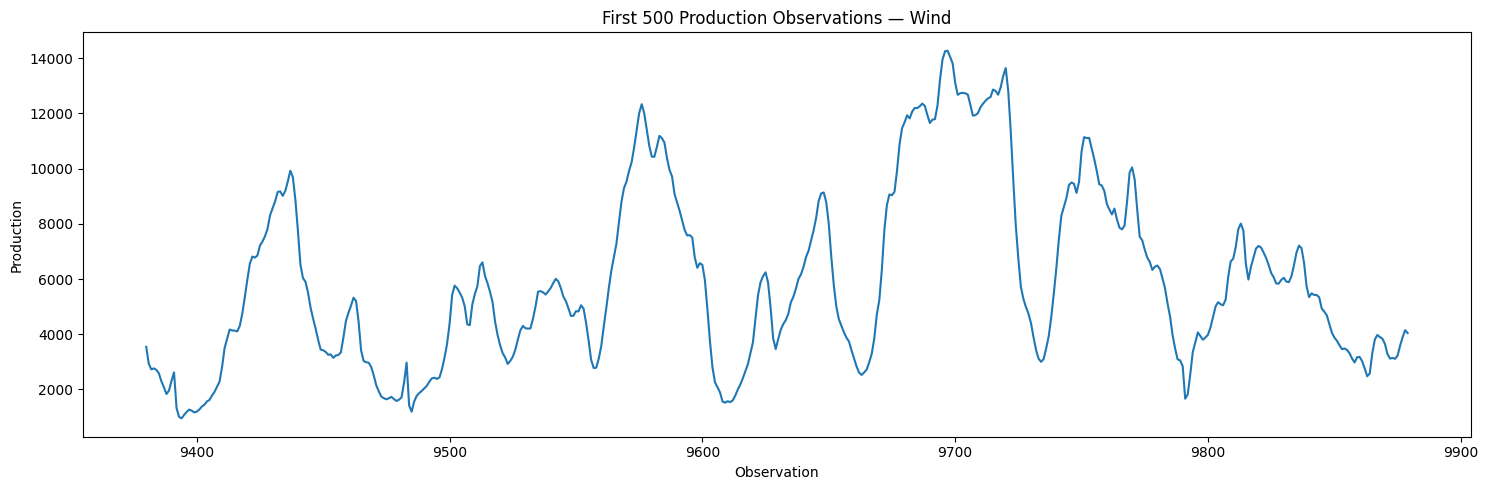

In [ ]:
sample_source = df["Source"].value_counts().index[0]

source_data = (
    df[df["Source"] == sample_source]
    .sort_values(["Date", "Start_Hour"])
)

plt.figure(figsize=(15, 5))

plt.plot(
    source_data["Production"].iloc[:500]
)

plt.title(
    f"First 500 Production Observations — {sample_source}"
)

plt.xlabel("Observation")
plt.ylabel("Production")
plt.tight_layout()
plt.show()

In [ ]:
numeric_columns = [
    "Start_Hour",
    "End_Hour",
    "Day_of_Year",
    "Production"
]

correlation_matrix = (
    df[numeric_columns]
    .corr()
)

display(correlation_matrix.round(3))

,Start_Hour,End_Hour,Day_of_Year,Production
Start_Hour,1.000,0.760,-0.000,0.094
End_Hour,0.760,1.000,-0.000,0.124
Day_of_Year,-0.000,-0.000,1.000,-0.045
Production,0.094,0.124,-0.045,1.000


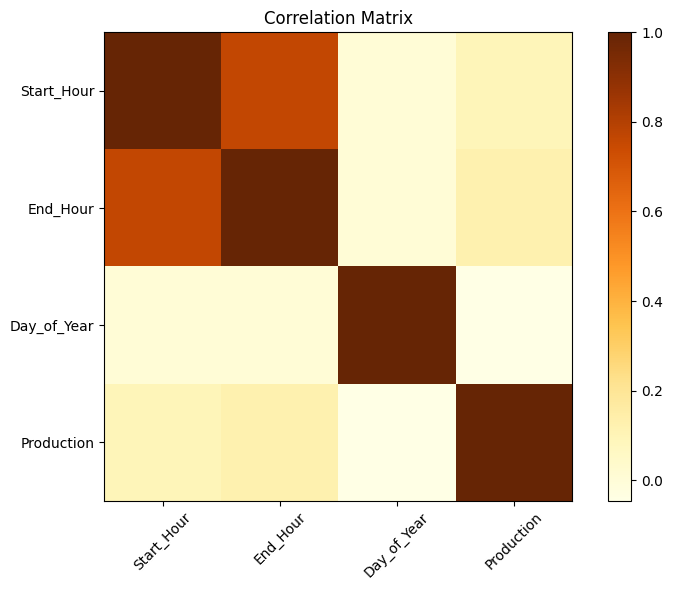

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation_matrix,
    interpolation="nearest",
    cmap="YlOrBr"
)

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [ ]:
for column in df.columns:

    print(
        f"{column}: "
        f"{df[column].nunique()} unique values"
    )

Date: 2161 unique values
Start_Hour: 24 unique values
End_Hour: 24 unique values
Source: 3 unique values
Day_of_Year: 366 unique values
Day_Name: 7 unique values
Month_Name: 12 unique values
Season: 4 unique values
Production: 14617 unique values
Year: 6 unique values
Production_Lag_1: 14617 unique values
Production_Lag_24: 14615 unique values
Production_Lag_168: 14592 unique values


In [ ]:
print("Correlation with Production:")

numeric_df = df.select_dtypes(include=np.number)

display(
    numeric_df.corr()["Production"]
    .sort_values(ascending=False)
)

Correlation with Production:


,Production
Production,1.000000
Production_Lag_1,0.971134
Production_Lag_24,0.474061
Year,0.185642
Production_Lag_168,0.146766
End_Hour,0.124452
Start_Hour,0.093576
Day_of_Year,-0.045464


In [ ]:
print("=" * 60)
print("ENERGY PRODUCTION DATASET — PROFILING SUMMARY")
print("=" * 60)

print(f"\nRows: {len(df):,}")
print(f"Columns: {len(df.columns)}")

print(
    f"\nDate range: "
    f"{df['Date'].min().date()} → "
    f"{df['Date'].max().date()}"
)

print(
    f"Unique dates: "
    f"{df['Date'].nunique():,}"
)

print("\nSources:")
print(df["Source"].value_counts())

print(
    f"\nMissing values: "
    f"{df.isnull().sum().sum():,}"
)

print(
    f"Duplicate rows: "
    f"{df.duplicated().sum():,}"
)

print(
    f"Duplicate Date+Hour+Source: "
    f"{df.duplicated(subset=key_columns).sum():,}"
)

print("\nProduction:")
print(df["Production"].describe().round(2))

print("\nRecords by year:")
print(df["Year"].value_counts().sort_index())

print("\nRecords by source:")
print(df["Source"].value_counts())

print("\n" + "=" * 60)

ENERGY PRODUCTION DATASET — PROFILING SUMMARY

Rows: 51,864
Columns: 13

Date range: 2020-01-01 → 2025-11-30
Unique dates: 2,161

Sources:
Source
Wind     42484
Solar     9378
Mixed        2
Name: count, dtype: int64

Missing values: 391
Duplicate rows: 0
Duplicate Date+Hour+Source: 6

Production:
count    51864.00
mean      6215.07
std       3978.36
min         58.00
25%       3111.00
50%       5372.00
75%       8501.00
max      23446.00
Name: Production, dtype: float64

Records by year:
Year
2020    8784
2021    8760
2022    8760
2023    8760
2024    8784
2025    8016
Name: count, dtype: int64

Records by source:
Source
Wind     42484
Solar     9378
Mixed        2
Name: count, dtype: int64

